# OpenMesh NYC: links, personal weather stations, airports

Twenty days of the NYC Mesh wireless network (January 2024), with the
personal weather stations (PWS) and ASOS airport stations around it: pulled,
checked against the OpenSense-1.0 format, and summarized.

Replaces, in one concise notebook, what `download_and_read_openmesh`,
`openmesh_dataset_example` and `read_pws_sample` each did (kept as they
were). Reading and checks are `core.opensense`; station summaries are
`src/stations.py`.

In [1]:
import sys
from pathlib import Path

import xarray as xr

sys.path.insert(0, str(Path.cwd().parent / "src"))
from core import viz_style as vs
from core.opensense import conventions as cv, example_data, plots
import stations

vs.use_style()

## Pull

The curated 20-day subset (~7 MB, cached after the first call). The full
record is on Zenodo: `python -m core.opensense.fetch --dataset openmesh`
(CML, CC-BY-4.0) and `--dataset openmesh_pws` (PWS, **CC-BY-NC-4.0**,
non-commercial).

In [2]:
data = example_data.load("openmesh", "20d", verbose=False)
cml, pws, asos = data["cml"], data["pws"], data["asos"]
{name: dict(ds.sizes) for name, ds in data.items()}

{'cml': {'cml_id': 75, 'sublink_id': 3, 'time': 28801},
 'pws': {'id': 37, 'time': 5552},
 'asos': {'time': 28266, 'id': 4}}

## Format check

OpenSense-1.0: dimensions, coordinate types, required metadata, and declared units.

In [3]:
cv.check_format(cml)

,check,passed,detail
0,"dimensions time, cml_id, sublink_id",True,
1,time is datetime64,True,datetime64[ns]
2,cml_id is a string,True,<U2
3,sublink_id is a string,True,object
4,"site coordinates, frequency, length",True,
5,rsl present (tsl optional),True,found ['rsl']
6,rsl in dBm,True,units='dBm'
7,frequency units declared,True,units='MHz'
8,length units declared,True,units='m'


## The network

75 links, **RSL only** - no transmitted power - in three bands (~5-6, 24 and
58-69 GHz). A link can carry up to three sublinks, but here 51 report one,
20 report two (mostly both directions of one band) and 4 report three. Most
links are short, and under ~2 km a 5-6 GHz sublink cannot see rain at all,
which is why `ingest_openmesh` picks the responsive band per link.

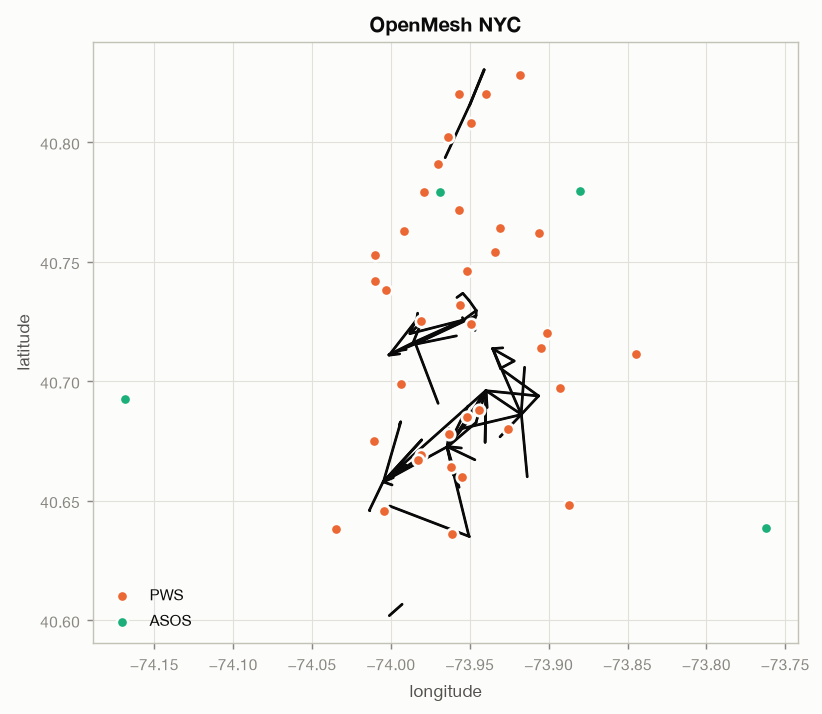

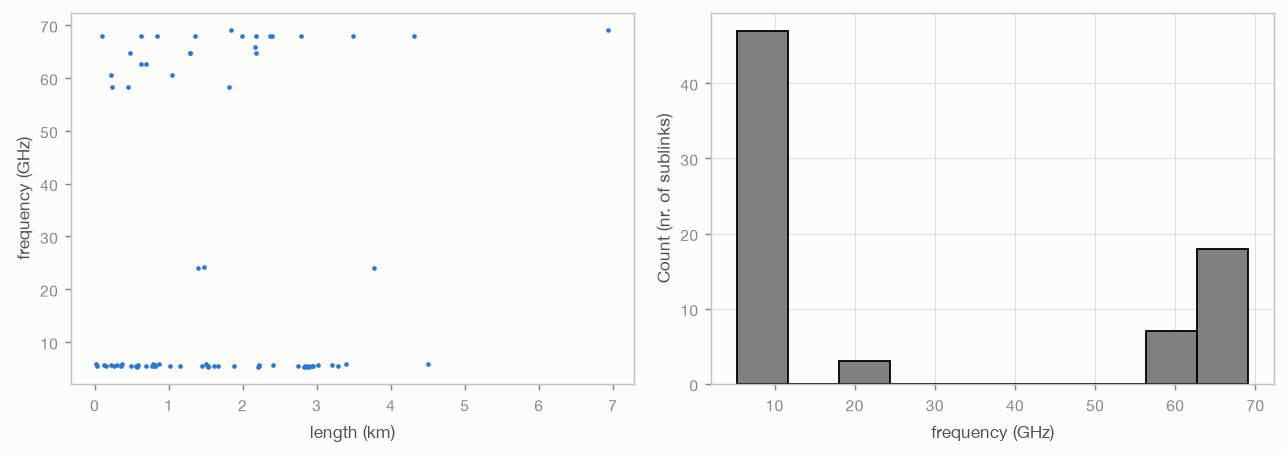

In [4]:
plots.network(None, cml, {"PWS": pws, "ASOS": asos}, title="OpenMesh NYC");
plots.metadata(cml);

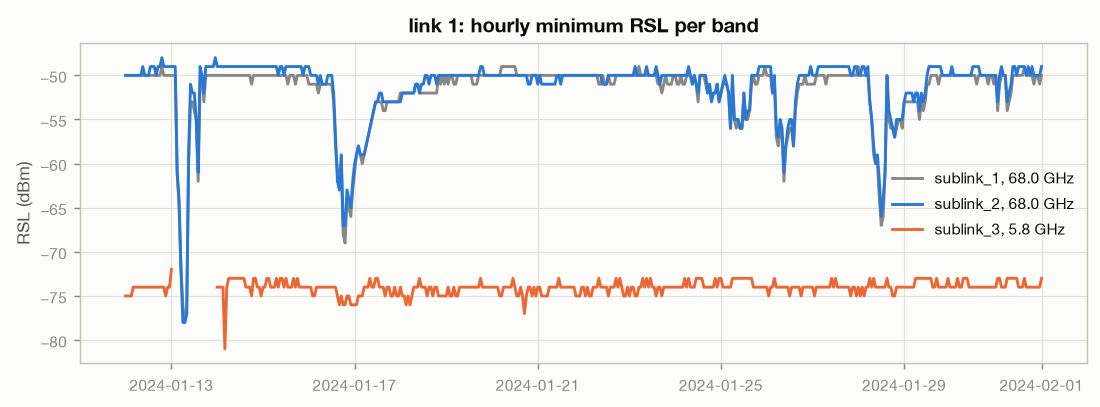

In [5]:
link = cml.sel(cml_id="1")                       # one of the few multi-band links
bands = {f"{s}, {float(link.frequency_ghz.sel(sublink_id=s)):.1f} GHz":
         link.rsl.sel(sublink_id=s).resample(time="1h").min()
         for s in link.sublink_id.values if link.frequency_ghz.sel(sublink_id=s).notnull()}
plots.series(bands, title=f"link {link.cml_id.item()}: hourly minimum RSL per band",
             ylabel="RSL (dBm)");

## Point sensors

Totals over the 20 days, and cumulative rain per station. Rule out before
using a station as a reference: **8 of the 37 PWS record under 1 mm in 20
days** against a median of ~70 mm for the rest - dead, not dry - and snow,
which tipping buckets do not measure (the 16th and 19th were snow days).

In [6]:
pws_totals = stations.totals(pws)
pws_totals.round(2).head(10)

,total_mm,wet_hours,peak_mm_h,missing,vs_median
station,,,,,
KNYNEWYO1921,121.75,27.60,28.70,0.03,1.96
KNYNEWYO1238,118.98,8.60,192.02,0.36,1.91
KNYNEWYO1313,103.16,31.02,13.72,0.03,1.66
KNYNEWYO1824,100.41,28.17,21.59,0.09,1.61
KNYNEWYO1288,98.73,26.33,20.32,0.24,1.59
KNYNEWYO1591,97.05,30.25,16.76,0.03,1.56
KNYNEWYO1796,95.81,30.07,16.76,0.03,1.54
KNYNEWYO1053,88.95,30.75,12.70,0.07,1.43
KNYNEWYO1298,85.59,27.47,16.76,0.08,1.38


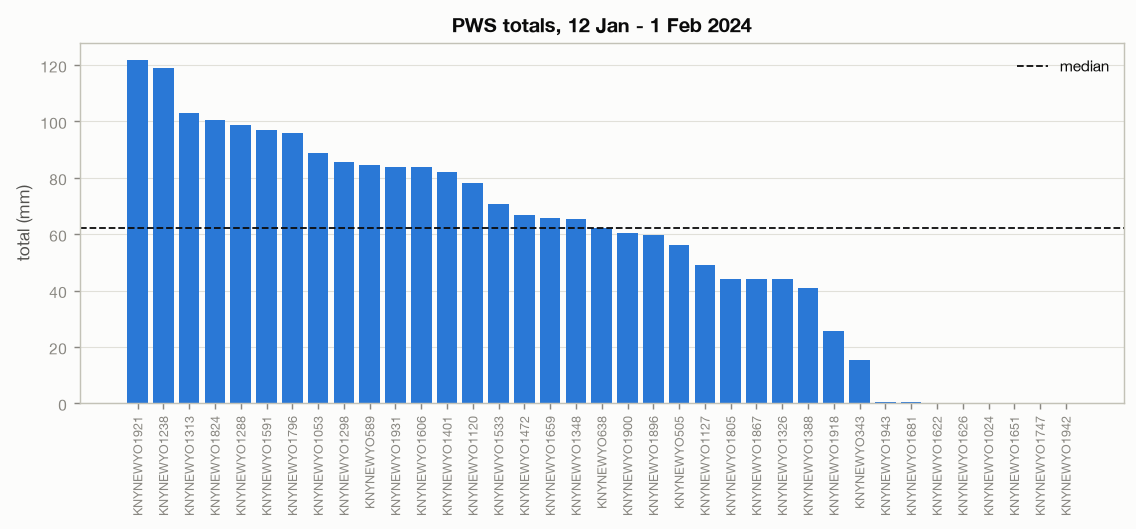

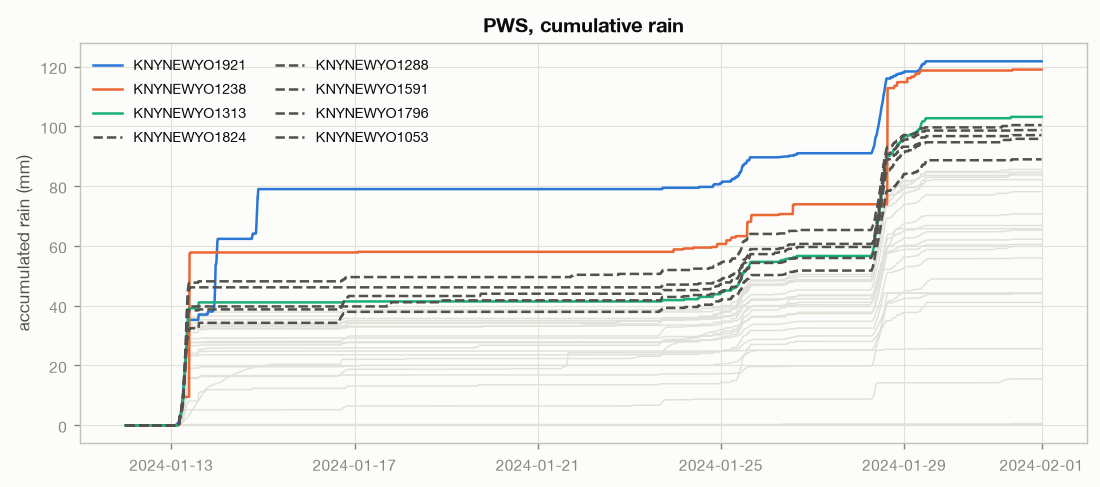

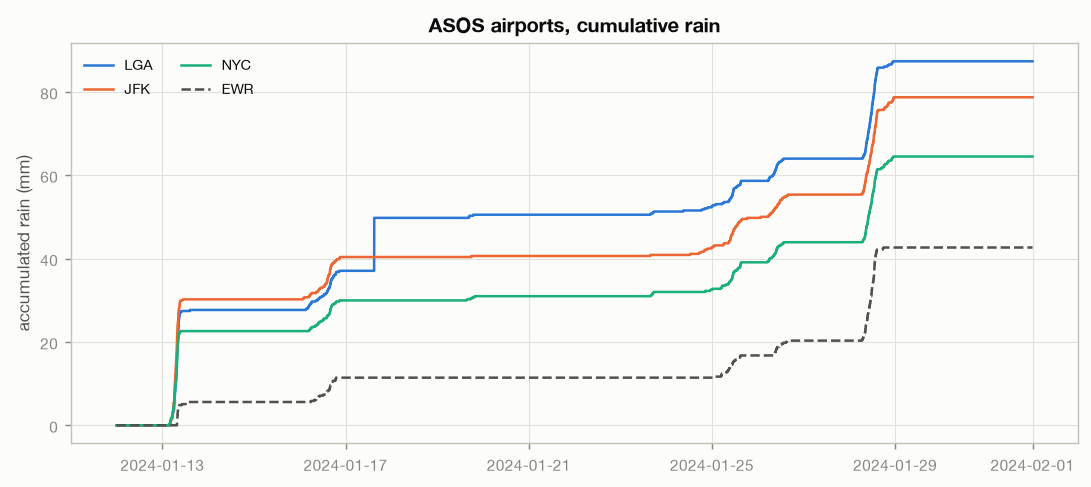

In [7]:
stations.plot_totals(pws_totals, title="PWS totals, 12 Jan - 1 Feb 2024");
stations.plot_accumulation(pws, title="PWS, cumulative rain");
stations.plot_accumulation(asos, top=4, title="ASOS airports, cumulative rain");

## Next

| to | where |
|---|---|
| retrieve rain from these links (RSL-only, band selection) | `projects/opensense_pipeline/src/ingest_openmesh.py` |
| radar (KOKX) over the network, rain vs snow days | `nexrad_rain_vs_snow.ipynb` |
| fetch more PWS / ASOS data | `wu_pipeline.ipynb`, `asos_pipeline.ipynb` (need network; WU needs an API key) |